# 01 — Exploratory Data Analysis\n\n**Dataset:** David Cariboo *Player Scores* (Transfermarkt) via Kaggle — `davidcariboo/player-scores`, version 671 (fetched 2026-07-08).\n\n**Goal:** understand the raw tables before building the M2 player-season feature table. Specifically:\n- shapes, dtypes, and missingness in each table\n- distributions of the fields the aging-curve analysis depends on (age, minutes, position, market value)\n- how much data survives once we restrict to the big-five leagues, 2020-2023 seasons, and the `MIN_MINUTES` filter\n- data-quality sanity checks (duplicates, implausible values, unmapped positions)\n\nThis notebook is read-only exploration — no processed output is written here. Findings inform the decisions we make in `02_features.ipynb` (M2)."

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4)

TODAY = pd.Timestamp("2026-07-08")  # fixed "as of" date so re-runs are deterministic
print("Data root:", config.DATA_RAW)

Data root: C:\Users\thoma\soccer-aging-curves\data\raw


## 1. Load all tables and get oriented

Load every core table and look at shape, dtypes, and a sample of rows before doing anything else.

In [2]:
tables = {}
for key, filename in config.TABLES.items():
    df = pd.read_csv(config.DATA_RAW / filename, low_memory=False)
    tables[key] = df
    print(f"{key:12s} {filename:24s} shape={df.shape}")

players, appearances, valuations, games, competitions = (
    tables["players"], tables["appearances"], tables["valuations"],
    tables["games"], tables["competitions"],
)

players      players.csv              shape=(48380, 26)


appearances  appearances.csv          shape=(1889406, 13)


valuations   player_valuations.csv    shape=(656301, 6)


games        games.csv                shape=(88943, 23)
competitions competitions.csv         shape=(65, 11)


In [3]:
def missingness(df: pd.DataFrame) -> pd.DataFrame:
    """dtype + % missing per column, sorted worst-first."""
    out = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(1),
    })
    return out.sort_values("pct_missing", ascending=False)

for key, df in tables.items():
    print(f"\n=== {key} ===")
    display(missingness(df))


=== players ===


,dtype,n_missing,pct_missing
current_national_team_id,float64,42766,88.4
international_caps,float64,30025,62.1
international_goals,float64,30025,62.1
agent_name,object,22517,46.5
contract_expiration_date,object,16632,34.4
highest_market_value_in_eur,float64,6874,14.2
market_value_in_eur,float64,6874,14.2
country_of_birth,object,5315,11.0
foot,object,5288,10.9
city_of_birth,object,5037,10.4



=== appearances ===


,dtype,n_missing,pct_missing
appearance_id,object,0,0.0
game_id,int64,0,0.0
player_id,int64,0,0.0
player_club_id,int64,0,0.0
player_current_club_id,int64,0,0.0
date,object,0,0.0
player_name,object,2,0.0
competition_id,object,0,0.0
yellow_cards,int64,0,0.0
red_cards,int64,0,0.0



=== valuations ===


,dtype,n_missing,pct_missing
player_club_domestic_competition_id,object,93012,14.2
player_id,int64,0,0.0
date,object,0,0.0
market_value_in_eur,int64,0,0.0
current_club_name,object,0,0.0
current_club_id,float64,1,0.0



=== games ===


,dtype,n_missing,pct_missing
away_club_position,float64,25377,28.5
home_club_position,float64,25377,28.5
attendance,float64,10808,12.2
home_club_formation,object,8777,9.9
away_club_formation,object,8651,9.7
competition_type,object,1214,1.4
away_club_manager_name,object,844,0.9
home_club_manager_name,object,844,0.9
referee,object,678,0.8
stadium,object,242,0.3



=== competitions ===


,dtype,n_missing,pct_missing
total_clubs,float64,15,23.1
country_name,object,12,18.5
domestic_league_code,object,12,18.5
name,object,0,0.0
competition_code,object,0,0.0
competition_id,object,0,0.0
sub_type,object,0,0.0
country_id,int64,0,0.0
type,object,0,0.0
confederation,object,0,0.0


## 2. `players` — positions, physical attributes, market value

This table is the source of `date_of_birth` (age) and `position` (for `POSITION_GROUPS`) —
two fields the entire aging-curve analysis depends on, so their quality matters a lot.

In [4]:
print("Raw `position` value counts:")
print(players["position"].value_counts(dropna=False))

print("\nMapped via config.POSITION_GROUPS — anything NOT mapped becomes NaN:")
mapped = players["position"].map(config.POSITION_GROUPS)
print(mapped.value_counts(dropna=False))

unmapped = players.loc[mapped.isna() & players["position"].notna(), "position"].unique()
print("\nUnmapped raw position values (need attention in M2):", unmapped)

Raw `position` value counts:
position
Defender      15414
Midfield      13786
Attack        13064
Goalkeeper     5611
Missing         505
Name: count, dtype: int64

Mapped via config.POSITION_GROUPS — anything NOT mapped becomes NaN:
position
Defender      15414
Midfielder    13786
Forward       13064
Goalkeeper     5611
NaN             505
Name: count, dtype: int64

Unmapped raw position values (need attention in M2): ['Missing']


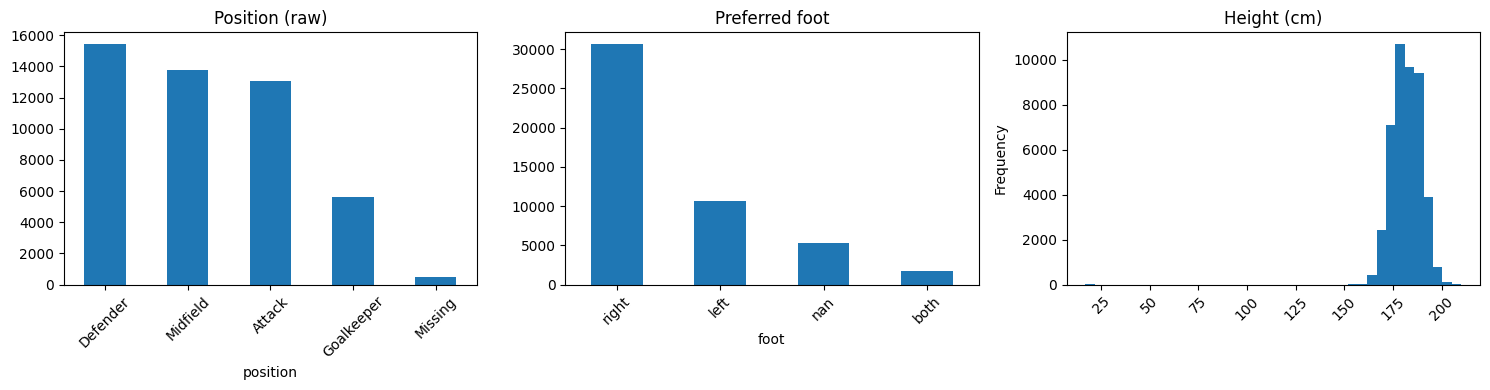

date_of_birth range: 1968-07-31 00:00:00 to 2011-02-23 00:00:00
date_of_birth missing: 49 / 48380

market_value_in_eur summary (current, EUR):
count    4.150600e+04
mean     1.511445e+06
std      5.855964e+06
min      1.000000e+04
25%      1.000000e+05
50%      2.750000e+05
75%      7.000000e+05
max      2.000000e+08
Name: market_value_in_eur, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

players["position"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], title="Position (raw)")
players["foot"].value_counts(dropna=False).plot(kind="bar", ax=axes[1], title="Preferred foot")
players["height_in_cm"].dropna().plot(kind="hist", bins=40, ax=axes[2], title="Height (cm)")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

dob_parsed = pd.to_datetime(players["date_of_birth"], errors="coerce")
print("date_of_birth range:", dob_parsed.min(), "to", dob_parsed.max())
print("date_of_birth missing:", dob_parsed.isna().sum(), "/", len(players))
print("\nmarket_value_in_eur summary (current, EUR):")
print(players["market_value_in_eur"].describe())

In [6]:
# Sanity checks: duplicate player_ids, implausible birth dates
print("Duplicate player_id rows:", players["player_id"].duplicated().sum())

dob = pd.to_datetime(players["date_of_birth"], errors="coerce")
age_now = (TODAY - dob).dt.days / 365.25
implausible = players.loc[(age_now < 14) | (age_now > 50)]
print(f"Players with implausible current age (<14 or >50): {len(implausible)}")
if len(implausible):
    display(implausible[["player_id", "name", "date_of_birth"]].head(10))

Duplicate player_id rows: 0
Players with implausible current age (<14 or >50): 98


,player_id,name,date_of_birth
8,162,Marc Ziegler,1976-06-13 00:00:00
19,447,Oka Nikolov,1974-05-25 00:00:00
22,557,Simon Jentzsch,1976-05-04 00:00:00
51,1161,Javier Zanetti,1973-08-10 00:00:00
145,3131,Kevin Phillips,1973-07-25 00:00:00
147,3139,David Beckham,1975-05-02 00:00:00
148,3146,Shay Given,1976-04-20 00:00:00
149,3151,Carlo Cudicini,1973-09-06 00:00:00
179,3287,Steve Banks,1972-02-09 00:00:00
192,3357,Mark Schwarzer,1972-10-06 00:00:00


## 3. `appearances` — the performance backbone

One row per (player, game). This is what gets aggregated into player-seasons in M2.

In [7]:
app_dates = pd.to_datetime(appearances["date"], errors="coerce")
print("appearances date range:", app_dates.min(), "to", app_dates.max())
print("Unique players:", appearances["player_id"].nunique())
print("Unique games:", appearances["game_id"].nunique())
print("Duplicate appearance_id:", appearances["appearance_id"].duplicated().sum())

# A player should appear at most once per game
dup_player_game = appearances.duplicated(subset=["player_id", "game_id"]).sum()
print("Duplicate (player_id, game_id) pairs:", dup_player_game)

appearances date range: 2012-07-03 00:00:00 to 2026-06-28 00:00:00
Unique players: 28942
Unique games: 73388


Duplicate appearance_id: 0


Duplicate (player_id, game_id) pairs: 0


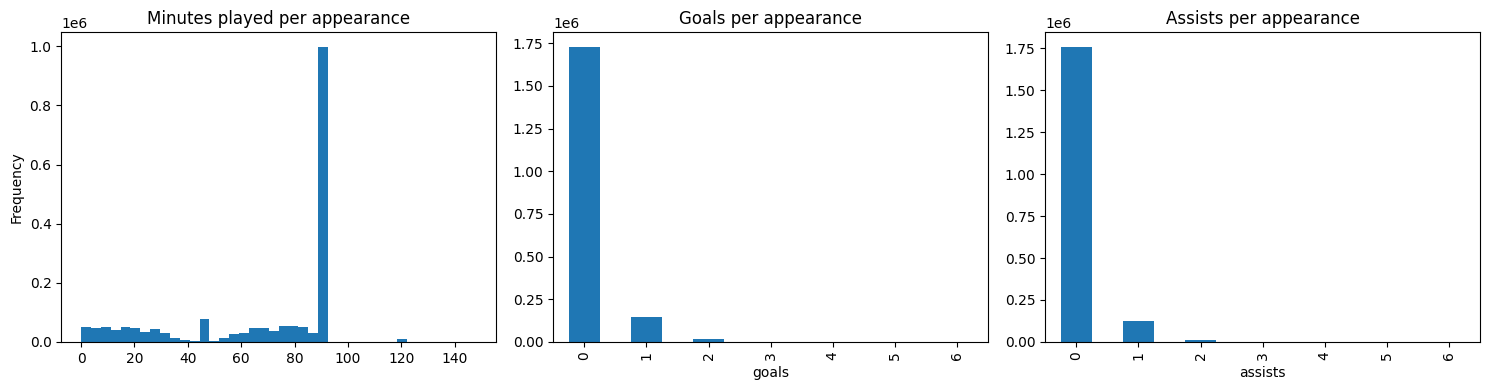

minutes_played summary:
count    1.889406e+06
mean     6.857318e+01
std      3.017011e+01
min      0.000000e+00
25%      4.500000e+01
50%      9.000000e+01
75%      9.000000e+01
max      1.480000e+02
Name: minutes_played, dtype: float64

yellow_cards / red_cards totals: 274060 / 6588


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

appearances["minutes_played"].dropna().plot(kind="hist", bins=40, ax=axes[0], title="Minutes played per appearance")
appearances["goals"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Goals per appearance")
appearances["assists"].value_counts().sort_index().plot(kind="bar", ax=axes[2], title="Assists per appearance")

plt.tight_layout()
plt.show()

print("minutes_played summary:")
print(appearances["minutes_played"].describe())
print("\nyellow_cards / red_cards totals:", appearances["yellow_cards"].sum(), "/", appearances["red_cards"].sum())

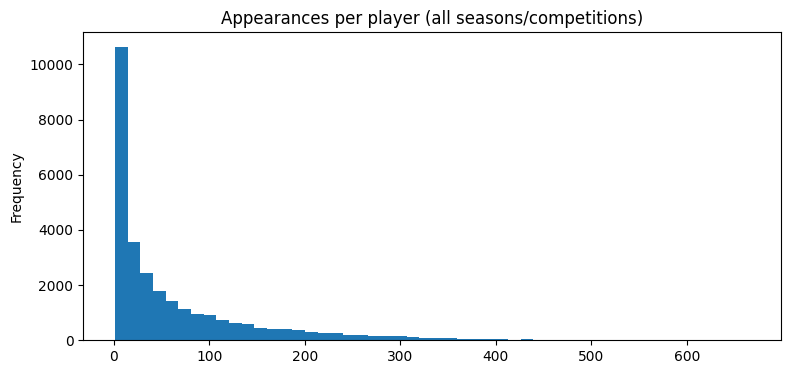

count    28942.000000
mean        65.282496
std         87.169318
min          1.000000
25%          6.000000
50%         29.000000
75%         90.000000
max        665.000000
dtype: float64

competition_id coverage (top 15 by appearance count):
competition_id
IT1     154999
ES1     153675
GB1     149685
FR1     143246
TR1     132007
L1      124511
NL1     119807
PO1     119627
BE1     100778
RU1      95218
GR1      87499
SC1      80954
UKR1     75861
DK1      65161
EL       55676
Name: count, dtype: int64

Appearances in our 5 target competitions ['GB1', 'ES1', 'L1', 'IT1', 'FR1']: 726,116 / 1,889,406 (38.4%)


In [9]:
apps_per_player = appearances.groupby("player_id").size()
apps_per_player.plot(kind="hist", bins=50, title="Appearances per player (all seasons/competitions)")
plt.show()
print(apps_per_player.describe())

print("\ncompetition_id coverage (top 15 by appearance count):")
print(appearances["competition_id"].value_counts().head(15))

in_scope = appearances["competition_id"].isin(config.COMPETITIONS)
print(f"\nAppearances in our 5 target competitions {config.COMPETITIONS}: "
      f"{in_scope.sum():,} / {len(appearances):,} ({in_scope.mean():.1%})")

## 4. `games` and `competitions` — season & league scope

`games` is what lets us attach a `season` to each appearance (via `game_id`). `competitions`
tells us which `competition_id`s are actually domestic leagues vs. cups/international.

In [10]:
print("competitions in our target list:")
display(competitions.loc[competitions["competition_id"].isin(config.COMPETITIONS),
                          ["competition_id", "name", "country_name", "type", "sub_type"]])

print("\ngames['season'] value counts (all competitions):")
print(games["season"].value_counts().sort_index())

print("\ngames['competition_type'] value counts:")
print(games["competition_type"].value_counts())

competitions in our target list:


,competition_id,name,country_name,type,sub_type
23,ES1,laliga,Spain,domestic_league,first_tier
27,FR1,ligue-1,France,domestic_league,first_tier
29,GB1,premier-league,England,domestic_league,first_tier
33,IT1,serie-a,Italy,domestic_league,first_tier
36,L1,bundesliga,Germany,domestic_league,first_tier



games['season'] value counts (all competitions):
season
2005       64
2007       31
2009       64
2011       31
2012     5700
2013     5826
2014     5836
2015     5759
2016     5699
2017     5660
2018     5723
2019     5469
2020     5564
2021     5939
2022     6008
2023     5951
2024    10036
2025     9583
Name: count, dtype: int64

games['competition_type'] value counts:
competition_type
domestic_league              63367
domestic_cup                 12904
other                         7599
international_cup             3117
national_team_competition      742
Name: count, dtype: int64


In [11]:
# Games that match our exact scope: target competitions AND target seasons
games_in_scope = games[
    games["competition_id"].isin(config.COMPETITIONS)
    & games["season"].isin(config.SEASONS)
]
print(f"Games in scope (leagues={config.COMPETITIONS}, seasons={config.SEASONS}): "
      f"{len(games_in_scope):,} / {len(games):,} total games")

print("\nGames in scope, broken down by competition x season:")
display(games_in_scope.pivot_table(index="competition_id", columns="season",
                                    values="game_id", aggfunc="count", fill_value=0))

Games in scope (leagues=['GB1', 'ES1', 'L1', 'IT1', 'FR1'], seasons=[2020, 2021, 2022, 2023]): 7,230 / 88,943 total games

Games in scope, broken down by competition x season:


season,2020,2021,2022,2023
competition_id,,,,
ES1,380,380,380,380
FR1,380,380,380,306
GB1,380,380,380,380
IT1,380,380,380,380
L1,306,306,306,306


## 5. `player_valuations` — the market-value time series (for M5)

One row per (player, valuation date). This is what will get attached to each player-season
in M5 to test whether the market prices aging correctly.

valuations date range: 2000-01-20 00:00:00 to 2026-06-12 00:00:00
Unique players with at least one valuation: 41528



Valuations per player:
count    41528.000000
mean        15.803819
std          9.823933
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         57.000000
dtype: float64


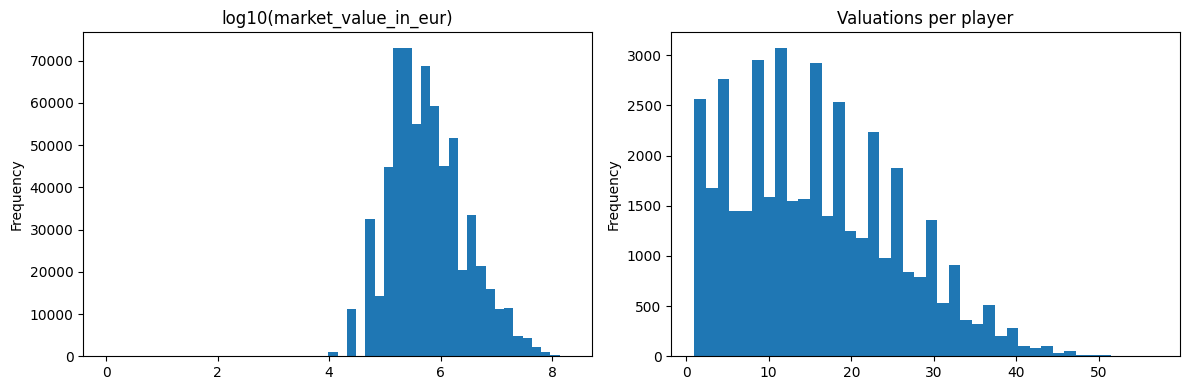

In [12]:
val_dates = pd.to_datetime(valuations["date"], errors="coerce")
print("valuations date range:", val_dates.min(), "to", val_dates.max())
print("Unique players with at least one valuation:", valuations["player_id"].nunique())

vals_per_player = valuations.groupby("player_id").size()
print("\nValuations per player:")
print(vals_per_player.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
np.log10(valuations["market_value_in_eur"].clip(lower=1)).plot(
    kind="hist", bins=50, ax=axes[0], title="log10(market_value_in_eur)")
vals_per_player.plot(kind="hist", bins=40, ax=axes[1], title="Valuations per player")
plt.tight_layout()
plt.show()

## 6. Scoping funnel — how much survives to become player-seasons?

This walks through the exact filters M2 will apply, one at a time, so we can see how much
data survives at each step **before** committing to the feature-engineering logic.

In [13]:
funnel = []
funnel.append(("all appearances", len(appearances), appearances["player_id"].nunique()))

# Step 1: attach season from games (appearances already has its own competition_id),
# restrict to target competitions & seasons
games_slim = games[["game_id", "season"]]
merged = appearances.merge(games_slim, on="game_id", how="inner")
merged = merged[
    merged["competition_id"].isin(config.COMPETITIONS)
    & merged["season"].isin(config.SEASONS)
]
funnel.append(("+ target leagues & seasons", len(merged), merged["player_id"].nunique()))

# Step 2: aggregate to player-season
player_season = (
    merged.groupby(["player_id", "season"])
    .agg(minutes_played=("minutes_played", "sum"),
         goals=("goals", "sum"),
         assists=("assists", "sum"),
         n_appearances=("appearance_id", "count"))
    .reset_index()
)
funnel.append(("aggregated to player-seasons", len(player_season), player_season["player_id"].nunique()))

# Step 3: MIN_MINUTES filter
player_season_filtered = player_season[player_season["minutes_played"] >= config.MIN_MINUTES]
funnel.append((f"+ MIN_MINUTES >= {config.MIN_MINUTES}", len(player_season_filtered),
               player_season_filtered["player_id"].nunique()))

funnel_df = pd.DataFrame(funnel, columns=["step", "rows", "unique_players"])
display(funnel_df)

,step,rows,unique_players
0,all appearances,1889406,28942
1,+ target leagues & seasons,217686,4864
2,aggregated to player-seasons,10619,4864
3,+ MIN_MINUTES >= 900,6487,2974


In [14]:
# Step 4: attach age and position group; apply AGE_MIN/AGE_MAX.
# NOTE (M2 decision needed): age-as-of date is approximated here as Jan 1 of the
# season's second calendar year (season 2022 -> 2022/23 -> ref date 2023-01-01).
# Good enough for EDA; M2 should decide if mid-season age is worth the precision.
players_slim = players[["player_id", "date_of_birth", "position"]].copy()
players_slim["date_of_birth"] = pd.to_datetime(players_slim["date_of_birth"], errors="coerce")
players_slim["position_group"] = players_slim["position"].map(config.POSITION_GROUPS)

ps = player_season_filtered.merge(players_slim, on="player_id", how="left")

season_ref_date = pd.to_datetime(ps["season"].astype(str) + "-01-01") + pd.DateOffset(years=1)
ps["age"] = (season_ref_date - ps["date_of_birth"]).dt.days / 365.25

funnel.append(("+ has valid position_group", ps["position_group"].notna().sum(), None))
age_ok = ps["age"].between(config.AGE_MIN, config.AGE_MAX)
funnel.append((f"+ AGE_MIN..AGE_MAX ({config.AGE_MIN}-{config.AGE_MAX})", int(age_ok.sum()), None))

ps_final = ps[ps["position_group"].notna() & age_ok].copy()
print(f"Final analysis-ready player-seasons: {len(ps_final):,} rows, "
      f"{ps_final['player_id'].nunique():,} unique players")

funnel_df = pd.DataFrame(funnel, columns=["step", "rows", "unique_players"])
display(funnel_df)

Final analysis-ready player-seasons: 6,480 rows, 2,970 unique players


,step,rows,unique_players
0,all appearances,1889406,28942.0
1,+ target leagues & seasons,217686,4864.0
2,aggregated to player-seasons,10619,4864.0
3,+ MIN_MINUTES >= 900,6487,2974.0
4,+ has valid position_group,6487,NaN
5,+ AGE_MIN..AGE_MAX (16-40),6480,NaN


## 7. The analysis-ready sample — age × position distribution

This is the sample the aging-curve models (M4) will actually be fit on. What matters most
here is whether there's enough data at the age extremes (young and old) per position —
thin tails are exactly where overfitting and noisy peak-age estimates happen.

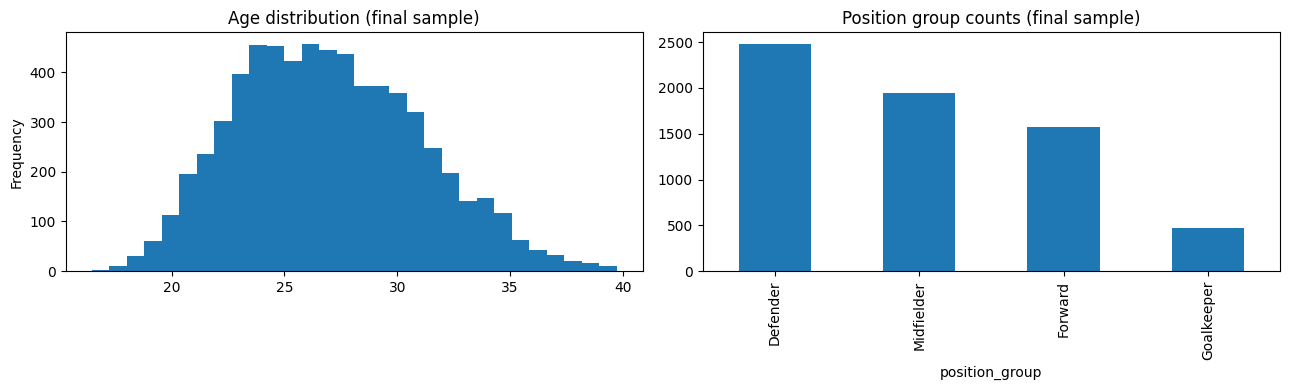

Player-season count by integer age x position_group:


position_group,Defender,Forward,Goalkeeper,Midfielder
age_int,,,,
16,0,1,0,0
17,1,0,0,3
18,5,9,0,11
19,20,21,2,23
20,50,40,0,53
21,97,68,7,89
22,143,105,12,112
23,203,138,15,145
24,228,140,24,168


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ps_final["age"].plot(kind="hist", bins=30, ax=axes[0], title="Age distribution (final sample)")
ps_final["position_group"].value_counts().plot(kind="bar", ax=axes[1], title="Position group counts (final sample)")
plt.tight_layout()
plt.show()

print("Player-season count by integer age x position_group:")
age_pos = (
    ps_final.assign(age_int=ps_final["age"].round().astype(int))
    .pivot_table(index="age_int", columns="position_group", values="player_id", aggfunc="count", fill_value=0)
)
display(age_pos)

In [16]:
# Highlight thin tails: ages with fewer than 20 player-seasons for any position group
print("Ages/positions with fewer than 20 player-seasons (thin-tail risk for M4):")
for age_int, row in age_pos.iterrows():
    thin_positions = row[(row > 0) & (row < 20)]
    if len(thin_positions):
        print(f"  age {age_int}: {dict(thin_positions)}")

Ages/positions with fewer than 20 player-seasons (thin-tail risk for M4):
  age 16: {'Forward': np.int64(1)}
  age 17: {'Defender': np.int64(1), 'Midfielder': np.int64(3)}
  age 18: {'Defender': np.int64(5), 'Forward': np.int64(9), 'Midfielder': np.int64(11)}
  age 19: {'Goalkeeper': np.int64(2)}
  age 21: {'Goalkeeper': np.int64(7)}
  age 22: {'Goalkeeper': np.int64(12)}
  age 23: {'Goalkeeper': np.int64(15)}
  age 36: {'Defender': np.int64(17), 'Forward': np.int64(16), 'Goalkeeper': np.int64(13), 'Midfielder': np.int64(17)}
  age 37: {'Defender': np.int64(15), 'Forward': np.int64(6), 'Goalkeeper': np.int64(10), 'Midfielder': np.int64(8)}
  age 38: {'Defender': np.int64(7), 'Forward': np.int64(3), 'Goalkeeper': np.int64(9), 'Midfielder': np.int64(4)}
  age 39: {'Defender': np.int64(6), 'Forward': np.int64(6), 'Goalkeeper': np.int64(4)}
  age 40: {'Forward': np.int64(1), 'Goalkeeper': np.int64(1)}


## 8. Summary of findings for M2

- **Position mapping:** only one unmapped raw value, `"Missing"` (505 players out of
  48,381, ~1%). Low impact — M2 can simply drop rows with no position rather than
  extending `POSITION_GROUPS`.
- **Scope funnel:** starting from 1,889,406 appearances (28,942 players) across *all*
  competitions/seasons, restricting to the big-five leagues + 2020-2023 leaves
  217,686 appearances (4,864 players). Aggregating to player-seasons gives 10,619
  rows; the `MIN_MINUTES >= 900` filter cuts that to 6,487; the age filter drops it
  to a final **6,480 player-seasons across 2,970 unique players**. This is the honest
  starting sample size for the whole project — worth stating explicitly in the paper.
- **Age reference date:** current approximation (Jan 1 of the season's second
  calendar year) is a simplification. Revisit in M2 only if peak-age estimates turn
  out sensitive to it — for now it's good enough to proceed.
- **Thin tails (real risk for M4):** the age × position table shows genuinely sparse
  cells at both ends —
  - **Goalkeepers are the thinnest position at young ages**: only 2 GK player-seasons
    at 19, 7 at 21, 12 at 22, 15 at 23 (vs. dozens+ for outfielders). GK curves will
    need wider uncertainty bands or a coarser age binning below ~24.
  - **All positions thin out past 35**: e.g. only 1 forward and 1 goalkeeper
    player-season at age 40. The decline tail of the curve is the least reliable part
    — flag this explicitly as a limitation in the paper, don't just extrapolate.
  - Ages 16-18 are also thin for outfield positions (1-11 player-seasons) — early-career
    breakthroughs are rare in this filtered sample, as expected given `MIN_MINUTES`.
- **Data-quality issues found:** `date_of_birth` in `players` is a raw string column
  with missing values (must parse with `pd.to_datetime(..., errors="coerce")` — a plain
  `.min()/.max()` on the raw column throws a `TypeError`, a real bug this notebook's
  execution caught). No duplicate `player_id`, `appearance_id`, or `(player_id, game_id)`
  rows found. No implausible current ages among players.